In [66]:
import sys
#sys.path.insert(1, '/home/santolam/MyPythonLibrary/MAR-RECAP/libmar/')
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
#sys.path.insert(1, '/Users/santolam/Documents/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

In [67]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [68]:
# Jasgulem ice core coordinates:
jasg_lat = 38.54063
jasg_lon = 72.269816

In [69]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [70]:
domain_2 = 'GRp'
domain_3 = 'GRp_bug'

In [18]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
# sourceData_3='/bettik/PROJECTS/pr-regional-climate/santolam/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [12]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [13]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve la carotte Jasgulem

# distance sur grille
dist = np.sqrt((ds_lat - jasg_lat)**2 + (ds_lon - jasg_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Caratéristique de la maille MAR ou se trouve le forage 2025")
print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())
print("Altitude :", ds_SH[iY, iX].item())

Caratéristique de la maille MAR ou se trouve le forage 2025
Indice Y : 26
Indice X : 47
Latitude : 38.54820251464844
Longitude : 72.30000305175781
Altitude : 5300.28369140625


/tmp/ipykernel_1736404/2256675531.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


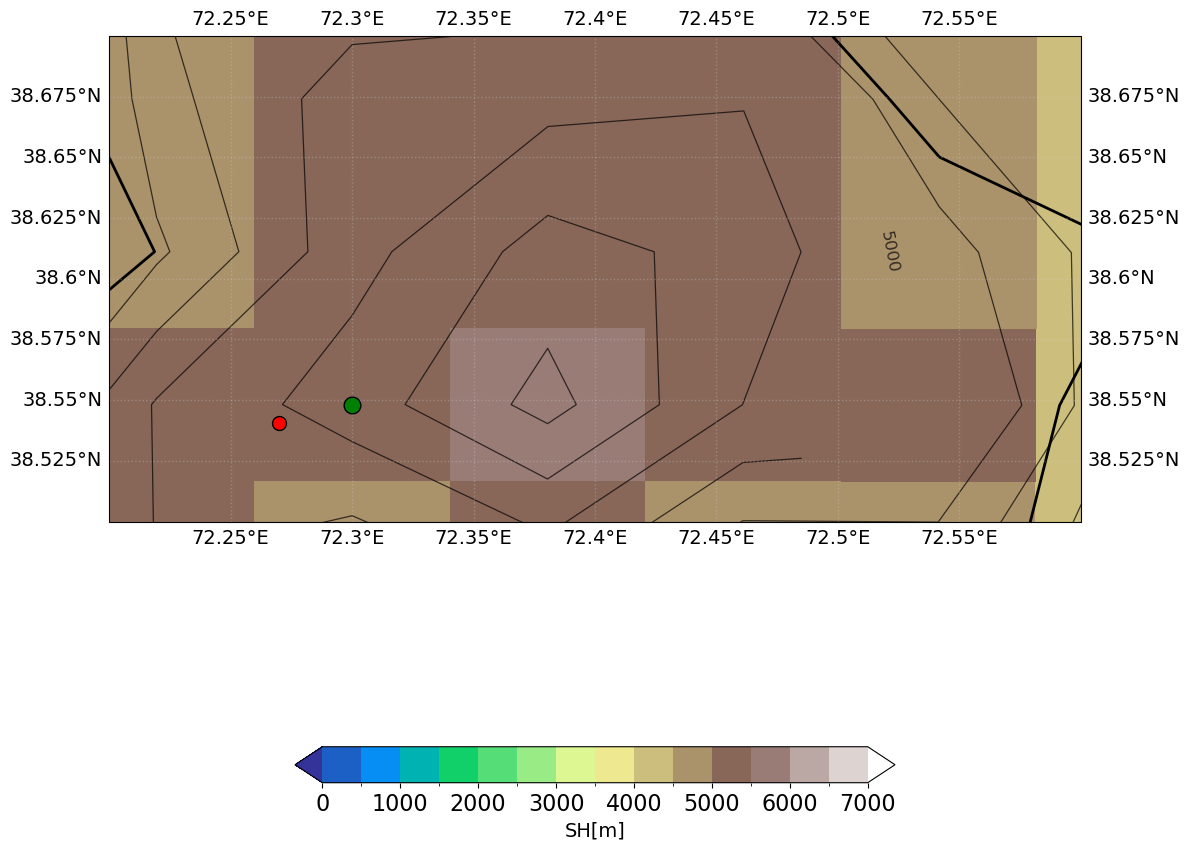

In [14]:
ice_level=32# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
#             levels=[10,ice_level,100],
#             hatches=['','X','X'],
#             colors="none",
#             transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[4400,4600,4800,5000,5200,5400,5600,5800,6000,6200,6400,6600,6800,7000],
                             colors="k", linewidths=0.9, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
ax.set_extent([72.2, 72.6, 38.5, 38.7], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="lightgray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Jasgulem ice core : red dot
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

# Identifier le point de grille ou se trouve la carotte Jasgulem
ax.plot(ds_lon[iY, iX], ds_lat[iY, iX],
        marker='o', markersize=12,
        markeredgecolor='black', markerfacecolor='green',
        transform=ccrs.PlateCarree())

plt.show()

/tmp/ipykernel_1736404/3268150799.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


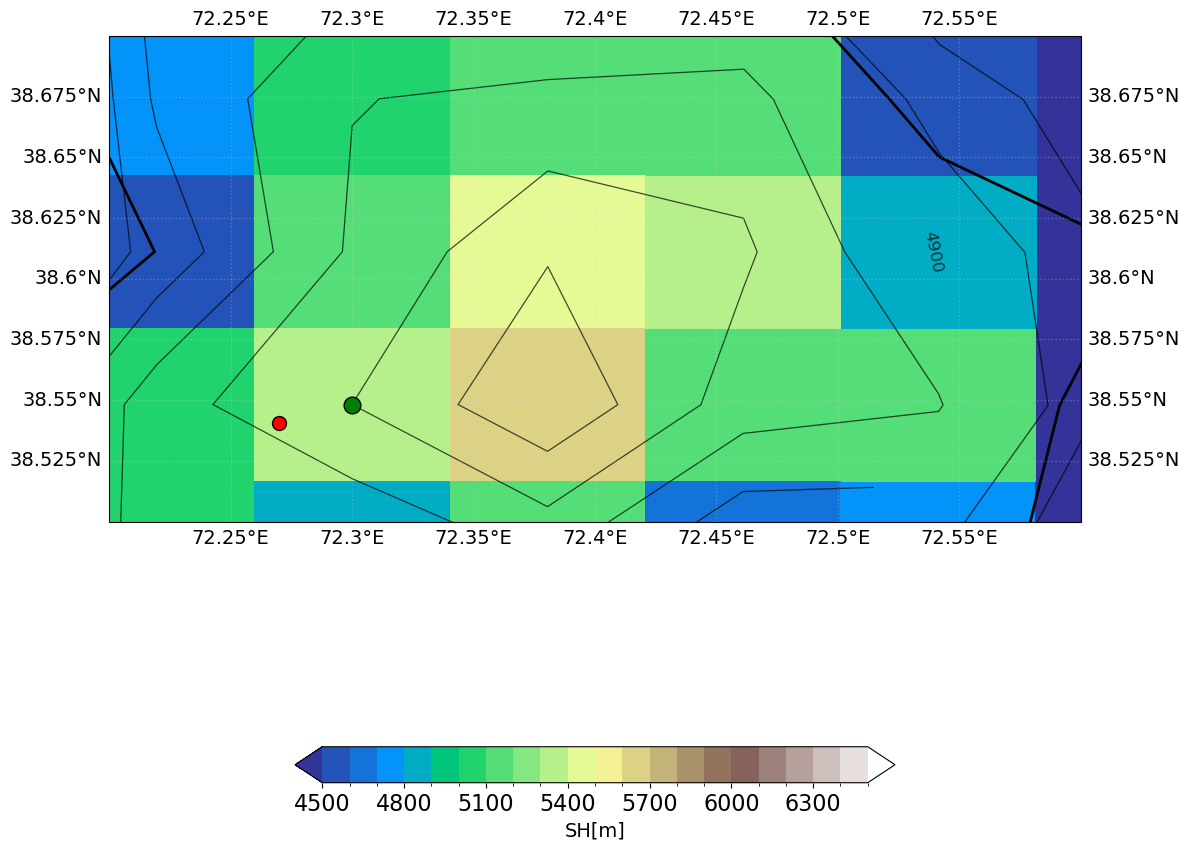

In [16]:
# Niveaux d'altitude entre 4500 et 6500 mètres
clevs = np.arange(4500, 6501, 100)  # Incréments de 100 m pour une transition progressive
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})

im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                    transform=ccrs.PlateCarree(),
                    cmap=cmap_mod,
                    norm=norm,
                    shading='auto')

# Contours pour les altitudes
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                 levels=np.arange(4500, 6501, 200),  # Niveaux de contours tous les 200 m
                 colors="k",
                 linewidths=0.9,
                 alpha=0.7,
                 transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")

# Contours pour la glace
ICE2 = ax.contour(ds_lon, ds_lat, ds_ICE,
                  levels=[ice_level],
                  colors="black",
                  linewidths=2.0,
                  alpha=1.0,
                  transform=ccrs.PlateCarree())
ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")

# Étendue géographique
ax.set_extent([72.2, 72.6, 38.5, 38.7], crs=ccrs.PlateCarree())

# Grilles et étiquettes
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color="lightgray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

# Barre de couleur
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

# Ajustement des sous-graphiques
fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Points spécifiques
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

ax.plot(ds_lon[iY, iX], ds_lat[iY, iX],
        marker='o', markersize=12,
        markeredgecolor='black', markerfacecolor='green',
        transform=ccrs.PlateCarree())

plt.show()

/tmp/ipykernel_1736404/4011659233.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


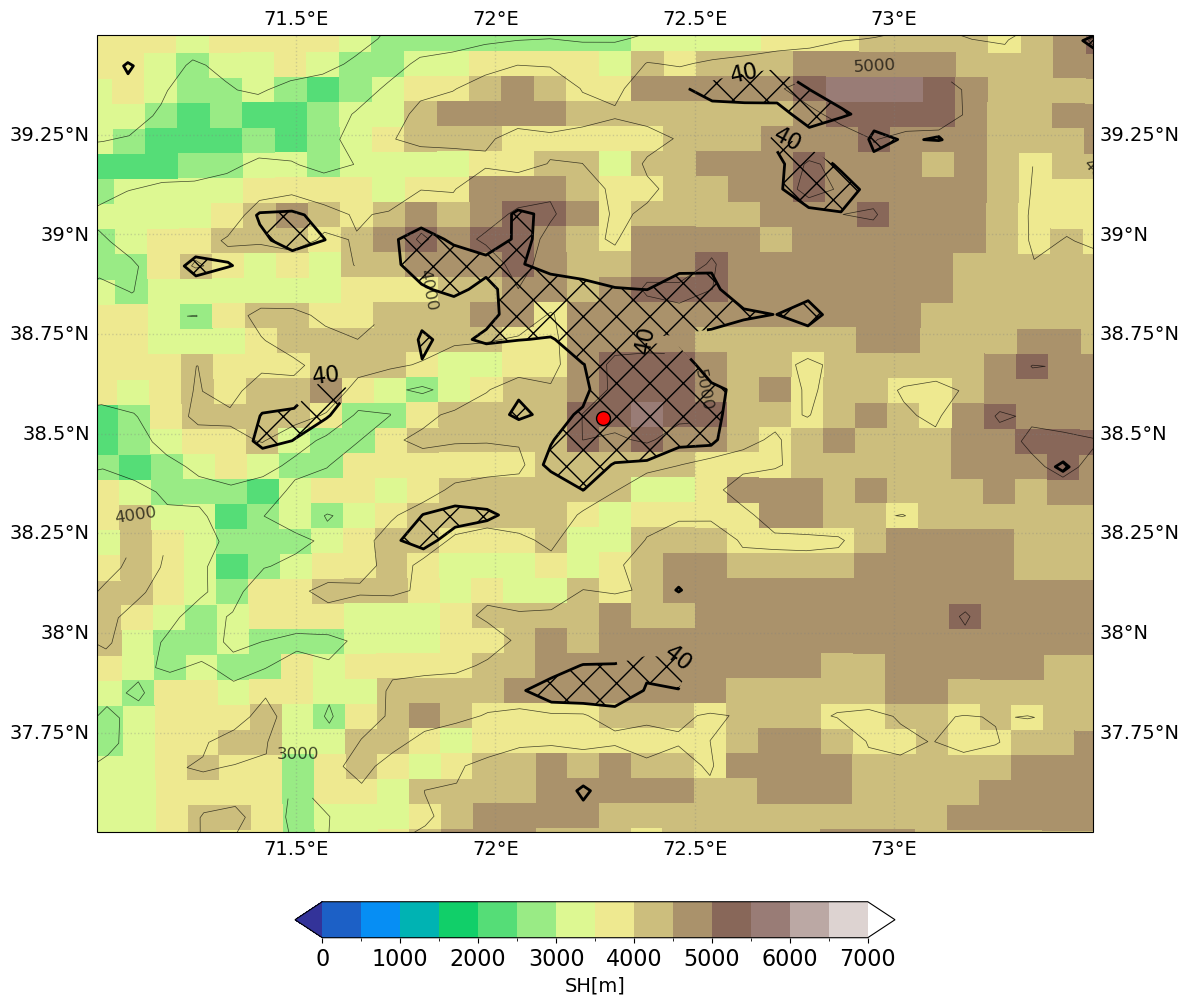

In [17]:
ice_level=40# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
ax.set_extent([71, 73.5, 37.5, 39.5], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Jasgulem ice core : red dot
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

plt.show()

### MAR datasets

# A ajouter ici : ds_ME, ds_RZ et ds_SW


In [19]:
variable='TTZ' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1950-2024.nc'
ds_TTZ= xr.open_dataset(sourceData_1+fileNameF).isel(ZTQLEV=0).TTZ.load()

ds_TTZ = ds_TTZ.assign_coords(X=np.round(ds_TTZ.X.values))
ds_TTZ = ds_TTZ.assign_coords(Y=np.round(ds_TTZ.Y.values))
ds_TTZ = ds_TTZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_TTZ = ds_TTZ[:,k:-k,k:-k]

In [20]:
variable='RF'

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1950-2024.nc'
ds_RF= xr.open_dataset(sourceData_1+fileNameF).RF.load()

ds_RF = ds_RF.assign_coords(X=np.round(ds_RF.X.values))
ds_RF = ds_RF.assign_coords(Y=np.round(ds_RF.Y.values))
ds_RF = ds_RF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RF = ds_RF[:,k:-k,k:-k]

In [21]:
variable='SF'

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1950-2024.nc'
ds_SF= xr.open_dataset(sourceData_1+fileNameF).SF.load()

ds_SF = ds_SF.assign_coords(X=np.round(ds_SF.X.values))
ds_SF = ds_SF.assign_coords(Y=np.round(ds_SF.Y.values))
ds_SF = ds_SF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SF = ds_SF[:,k:-k,k:-k]

In [57]:
variable='ME' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_ME= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRp_bug/spin2/work/monthly/'+fileNameF).ME.isel(SECTOR1_1=0).load()

ds_ME = ds_ME.assign_coords(X=np.round(ds_ME.X.values))
ds_ME = ds_ME.assign_coords(Y=np.round(ds_ME.Y.values))
ds_ME = ds_ME.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_ME = ds_ME[:,k:-k,k:-k]
ds_ME = - ds_ME



# Variable ME pas encore extraite pour nouvelles simues

# variable='ME' 

# fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
# ds_ME= xr.open_dataset(sourceData_1+fileNameF).ME.isel(SECTOR1_1=0).load()

# ds_ME = ds_ME.assign_coords(X=np.round(ds_ME.X.values))
# ds_ME = ds_ME.assign_coords(Y=np.round(ds_ME.Y.values))
# ds_ME = ds_ME.rename({'TIME': 'time'})

# # Enlever k pixels sur les contours
# ds_ME = ds_ME[:,k:-k,k:-k]
#ds_ME = - ds_ME

In [23]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1950-2024.nc'
ds_SMB= xr.open_dataset(sourceData_1+fileNameF).SMB.isel(SECTOR=0).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,k:-k,k:-k]

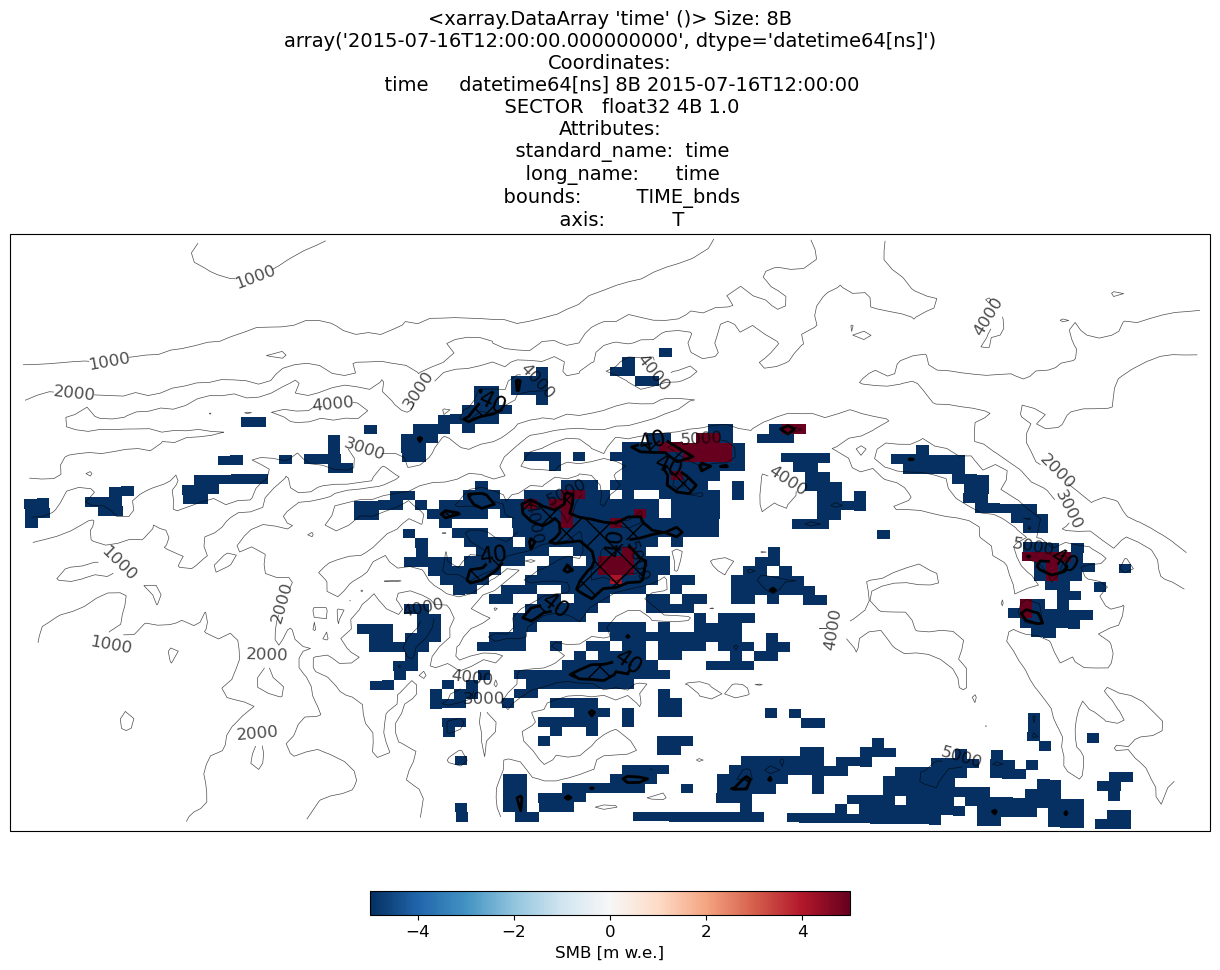

In [18]:
ice_level = 40
time_id=6+35*12

# Définir les niveaux pour la colorbar (de -5 à 3)
vmin, vmax = -5, 5
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# Colormap adaptée pour une échelle centrée sur 0
cmap_mod = plt.get_cmap('RdBu_r')  # Rouge-Bleu inversé

fig, ax = plt.subplots(figsize=(20, 16), subplot_kw={'projection': ccrs.PlateCarree()})

smb_data = ds_SMB.isel(time=time_id)
smb_mask = np.ma.masked_where(smb_data == 0, smb_data)

smb = ax.pcolormesh(
    ds_lon, ds_lat, smb_mask,
    transform=ccrs.PlateCarree(),
    cmap=cmap_mod,  # Utilisation de la colormap RdBu_r
    norm=norm,      # Normalisation pour la plage -5 à 3
    shading="auto")

# Ajout de la colorbar
cbar = fig.colorbar(smb, ax=ax, orientation="horizontal", pad=0.05, fraction=0.02)
cbar.set_label("SMB [m w.e.]", fontsize=12)
cbar.ax.tick_params(labelsize=12)

# Contours pour la glace
ICE1 = ax.contourf(ds_lon, ds_lat, ds_ICE,
                   levels=[10, ice_level, 100],
                   hatches=['', 'X', 'X'],
                   colors="none",
                   transform=ccrs.PlateCarree())

# Contours pour l'altitude
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                 levels=[1000, 2000, 3000, 4000, 5000, 6000, 7000],
                 colors="k", linewidths=0.5, alpha=0.7,
                 transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")

# Contours pour la glace (niveau spécifique)
ICE2 = ax.contour(ds_lon, ds_lat, ds_ICE,
                  levels=[ice_level],
                  colors="black", linewidths=2.0, alpha=1.0,
                  transform=ccrs.PlateCarree())
ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")

# Ajustements et titre
fig.subplots_adjust(left=0.2, right=0.8, top=0.9, bottom=0.15)
ax.set_title(ds_SMB.time.isel(time=time_id), fontsize=14)

plt.show()

In [25]:
##Fedchenko Accumulation basin

mask_Fed = (
    (ds_lon >= 72.25) & (ds_lon <= 72.5) &
    (ds_lat >= 38.5) & (ds_lat <= 38.7)
)

SH_Fed = ds_SH.where(mask_Fed, drop=True)
lon_Fed = ds_lon.where(mask_Fed, drop=True)
lat_Fed = ds_lat.where(mask_Fed, drop=True)

ds_TTZ_Fed = ds_TTZ.where(mask_Fed, drop=True)
ds_RF_Fed = ds_RF.where(mask_Fed, drop=True)
ds_SF_Fed = ds_SF.where(mask_Fed, drop=True)
# ds_ME_Fed = ds_ME.where(mask_Fed, drop=True)
ds_SMB_Fed = ds_SMB.where(mask_Fed, drop=True)

/tmp/ipykernel_1481031/229444792.py:11: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(ds_lon_jasg, ds_lat_jasg, ds_SH_jasg, shading='auto')#,vmin=0, vmax=100)


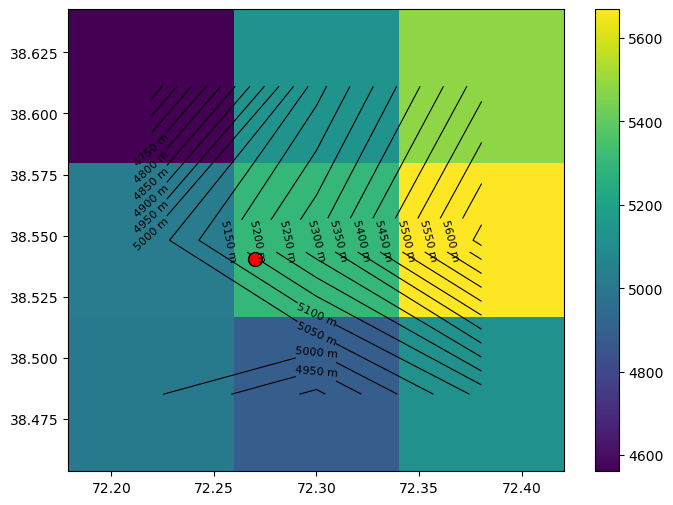

In [20]:
ds_SH_jasg = ds_SH.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2))
ds_lat_jasg = ds_lat.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2))
ds_lon_jasg = ds_lon.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2))

X, Y = np.meshgrid([0,1,2], [0,1,2])

levels = np.arange(3000, 6500, 50)  

fig, ax = plt.subplots(figsize=(8,6))

m = ax.pcolormesh(ds_lon_jasg, ds_lat_jasg, ds_SH_jasg, shading='auto')#,vmin=0, vmax=100)                   
contours = ax.contour(ds_lon_jasg, ds_lat_jasg, ds_SH_jasg, levels=levels, colors='black', linewidths=0.8)

ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         


cbar = fig.colorbar(m, ax=ax, orientation='vertical')
# cbar.set_label("Ice mask")

# Jasgulem ice core
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red')
        # transform=ccrs.PlateCarree())

plt.show()

## Sorties de MAR au point de Grille JASGULEM ICE CORE

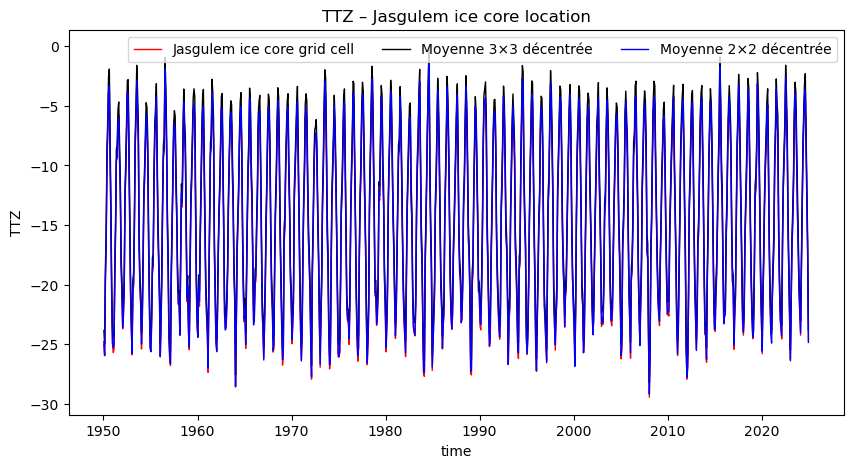

In [27]:
# TTZ at Jasgulem ice core site

plt.figure(figsize=(10,5))

# Plot 9 points individuellement
# for i in range(3):
#     for j in range(3):
#         ds_TTZ.isel(Y=iY-1+i, X=iX-1+j).plot(label=f"Y={iY-1+i}, X={iX-1+j}", alpha=0.5)

ds_TTZ_jasg =  ds_TTZ.isel(Y=iY, X=iX)
ds_TTZ_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="red")

# ds_TTZ_jasg =  ds_TTZ.isel(Y=iY-1, X=iX)
# ds_TTZ_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="black")
# ds_TTZ_jasg =  ds_TTZ.isel(Y=iY-2, X=iX)
# ds_TTZ_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="purple")

# Moyenne 3×3 grid cells close to drilling site, centrée sur drilling site
ds_TTZ_jasg_mean = ds_TTZ.isel(Y=slice(iY-1, iY+2),
                          X=slice(iX-1, iX+2)).mean(dim=["Y", "X"])
ds_TTZ_jasg_mean.plot(label="Moyenne 3×3 décentrée", linewidth=1, color="black")

# Moyenne 2×2 grid cells close to drilling site, drilling site au sud-west de la zone considérée
ds_TTZ_jasg_mean = ds_TTZ.isel(Y=slice(iY-1, iY+1),
                          X=slice(iX, iX+2)).mean(dim=["Y", "X"])
ds_TTZ_jasg_mean.plot(label="Moyenne 2×2 décentrée", linewidth=1, color="blue")

# Moyenne 3×3 grid cells close to drilling site, drilling site au sud-west de la zone considérée
# ds_TTZ_jasg_mean = ds_TTZ.isel(Y=slice(iY-2, iY)).mean(dim=["Y", "X"])
# ds_TTZ_jasg_mean.plot(label="Moyenne 3×3 décentrée", linewidth=1, color="orange")

plt.legend(ncol=3)
plt.title("TTZ – Jasgulem ice core location")
plt.ylabel("TTZ")
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/grou

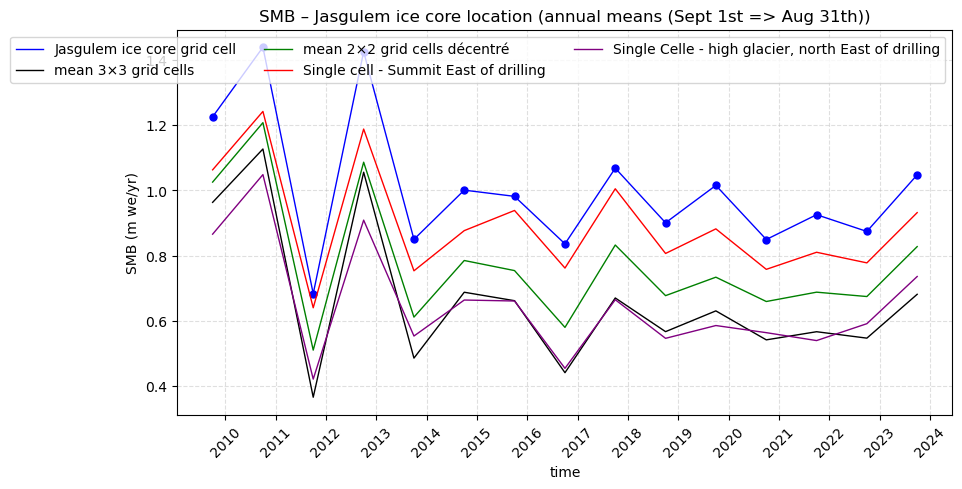

In [28]:
#SMB Annual (from Sept 1 to Aug 31, fpr comparison with ice core record)

plt.figure(figsize=(10,5))

# Point précis Jasgulem
ds_SMB_jasg = ds_SMB.isel(Y=iY, X=iX)
ds_SMB_jasg_annual = ds_SMB_jasg.resample(time="A-SEP").sum().sel(time=slice("2009-09-01", "2024-08-31"))/1000

ds_SMB_jasg_annual.plot(label="Jasgulem ice core grid cell", linewidth=1, color="blue")

plt.plot(ds_SMB_jasg_annual.time,
         ds_SMB_jasg_annual,
         'o', color='blue', markersize=5)

# Moyenne 3×3 centrée
ds_SMB_jasg_mean = ds_SMB.isel(Y=slice(iY-1, iY+2),
                               X=slice(iX-1, iX+2)).mean(dim=["Y", "X"])
ds_SMB_jasg_mean_annual = ds_SMB_jasg_mean.resample(time="A-SEP").sum().sel(time=slice("2009-09-01", "2024-08-31"))/1000
ds_SMB_jasg_mean_annual.plot(label="mean 3×3 grid cells", linewidth=1, color="black")

# Moyenne 2×2 décentrée
ds_SMB_jasg_mean = ds_SMB.isel(Y=slice(iY-1, iY+1),
                               X=slice(iX, iX+2)).mean(dim=["Y", "X"])
ds_SMB_jasg_mean_annual = ds_SMB_jasg_mean.resample(time="A-SEP").sum().sel(time=slice("2009-09-01", "2024-08-31"))/1000
ds_SMB_jasg_mean_annual.plot(label="mean 2×2 grid cells décentré", linewidth=1, color="green")

# # Moyenne 3×3 décentrée
# ds_SMB_jasg_mean = ds_SMB.isel(Y=slice(iY-2, iY+1),
#                                X=slice(iX, iX+3)).mean(dim=["Y", "X"])
# ds_SMB_jasg_mean_annual = ds_SMB_jasg_mean.resample(time="A-SEP").sum().sel(time=slice("2009-09-01", "2024-08-31"))/1000
# ds_SMB_jasg_mean_annual.plot(label="mean 3×3 grid cells décentré", linewidth=1, color="red")


# maille plus haute que Jasgulem
ds_SMB_jasg_mean = ds_SMB.isel(Y=iY,X=iX+1)
ds_SMB_jasg_mean_annual = ds_SMB_jasg_mean.resample(time="A-SEP").sum().sel(time=slice("2009-09-01", "2024-08-31"))/1000
ds_SMB_jasg_mean_annual.plot(label="Single cell - Summit East of drilling", linewidth=1, color="red")

# maille #2 plus haute que Jasgulem
ds_SMB_jasg_mean = ds_SMB.isel(Y=iY-1,X=iX+1)
ds_SMB_jasg_mean_annual = ds_SMB_jasg_mean.resample(time="A-SEP").sum().sel(time=slice("2009-09-01", "2024-08-31"))/1000
ds_SMB_jasg_mean_annual.plot(label="Single Celle - high glacier, north East of drilling", linewidth=1, color="purple")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Jasgulem ice core location (annual means (Sept 1st => Aug 31th))")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

## Composantes du SMB au point de grille du forage 2025

In [58]:
# TEMPORAIRE
# SMB = SF + RF - RU - SU - SW
# SMB = SF - ME + RZ - SU - SW

smb_dataset = {
    "SF": ds_SF,
    "ME":  ds_ME,   
}

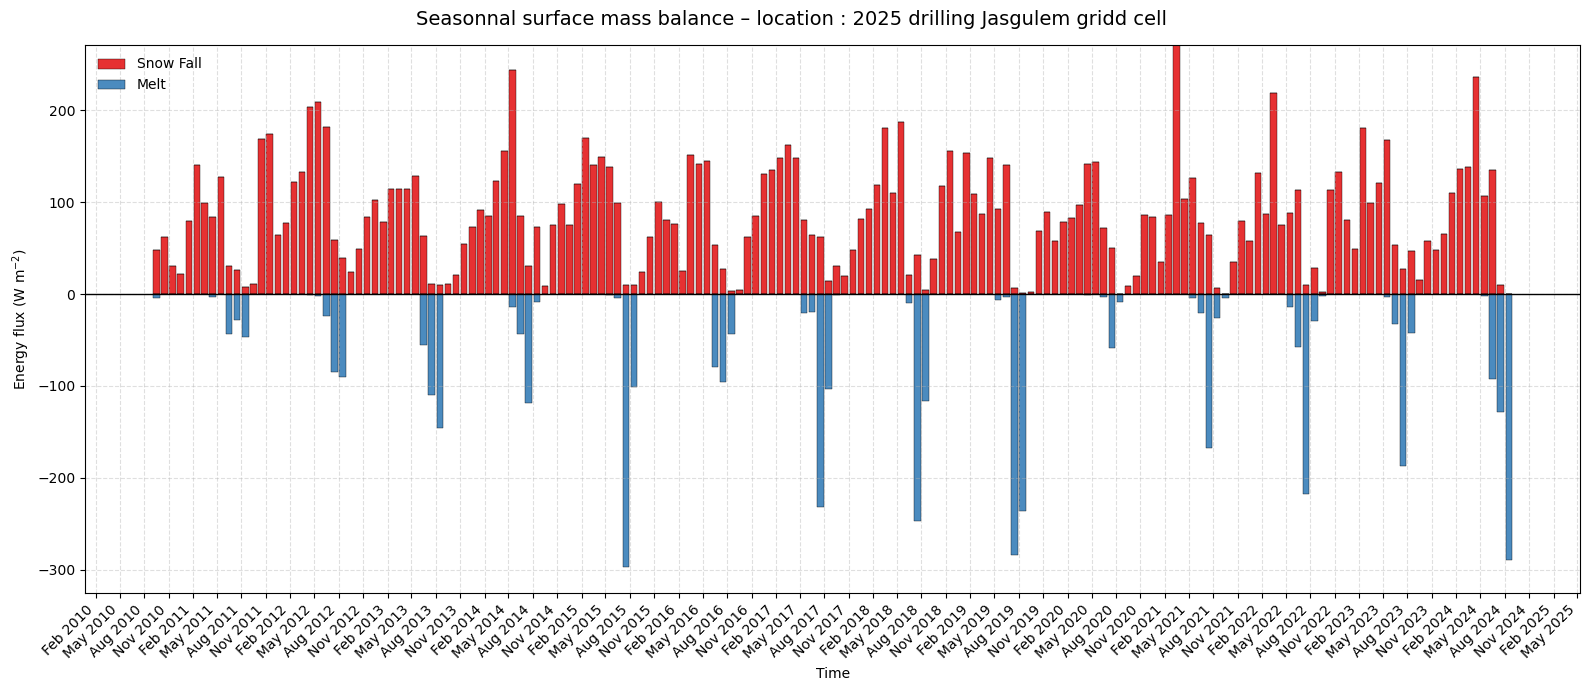

In [59]:
# TEMPORAIRE
# Période cible
start_date = "2010-09-01"
end_date = "2024-08-31"

# Filtrer les données temporellement
smb_filtered = {}
for key, da in smb_dataset.items():
    smb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
smb_jasg = {}
for key, da in smb_filtered.items():
    smb_jasg[key] = da.isel(Y=iY, X=iX)


# Composantes du SMB
components = ["SF", "ME"]
labels = {
    "SF": "Snow Fall",
    "ME": "Melt",
}

# Couleurs pour les histos
colors = {
    "SF": "#e41a1c", 
    "ME": "#377eb8", 
}

# Temps et données
time = smb_jasg[components[0]].time.values
data = np.array([smb_jasg[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(16, 7))

# Initialisation cumul
cumulative_pos = np.zeros_like(data[0])
cumulative_neg = np.zeros_like(data[0])

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        time,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        time,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("Energy flux (W m$^{-2}$)")
ax.set_xlabel("Time")

# Format date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Seasonnal surface mass balance – location : 2025 drilling Jasgulem gridd cell ", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

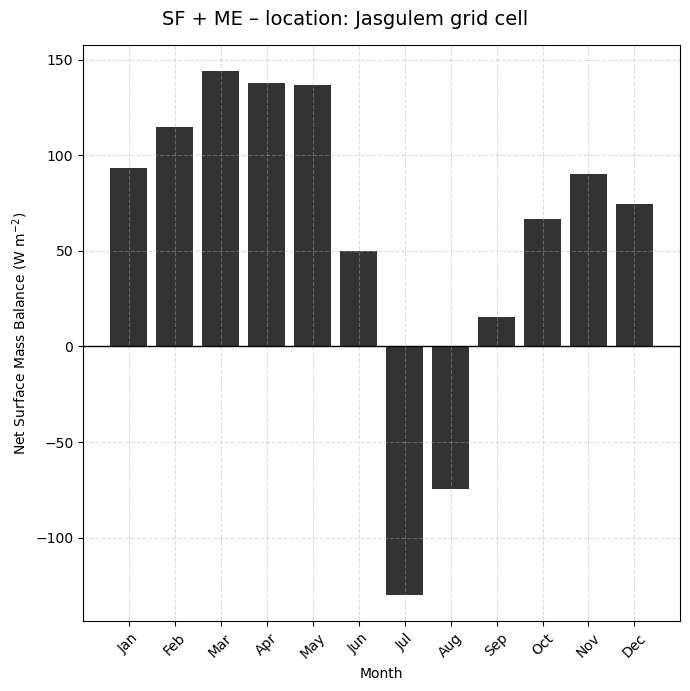

In [63]:
# Période cible
start_date = "2010-09-01"
end_date = "2024-08-31"

# Filtrer les données temporellement
smb_filtered = {}
for key, da in smb_dataset.items():
    smb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
seb_jasg = {}
for key, da in smb_filtered.items():
    smb_jasg[key] = da.isel(Y=iY, X=iX)

# Calcul SEB net
smb_net = (
    smb_jasg["SF"]
    + smb_jasg["ME"]
)

# Climatologie mensuelle
smb_net = smb_net.groupby("time.month").mean()

# Données pour plot
months = np.arange(1, 13)
values = smb_net.values

fig, ax = plt.subplots(figsize=(7, 7))

ax.bar(
    months,
    values,
    width=0.8,
    color="black",
    alpha=0.8
)

ax.axhline(0, color="black", linewidth=1)

ax.set_xticks(months)
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=45
)

ax.set_ylabel("Net Surface Mass Balance (W m$^{-2}$)")
ax.set_xlabel("Month")

ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("SF + ME – location: Jasgulem grid cell", fontsize=14)

plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'AS-SEP' is deprecated and will be removed in a future version, please use 'YS-SEP' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_1736404/3031556158.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


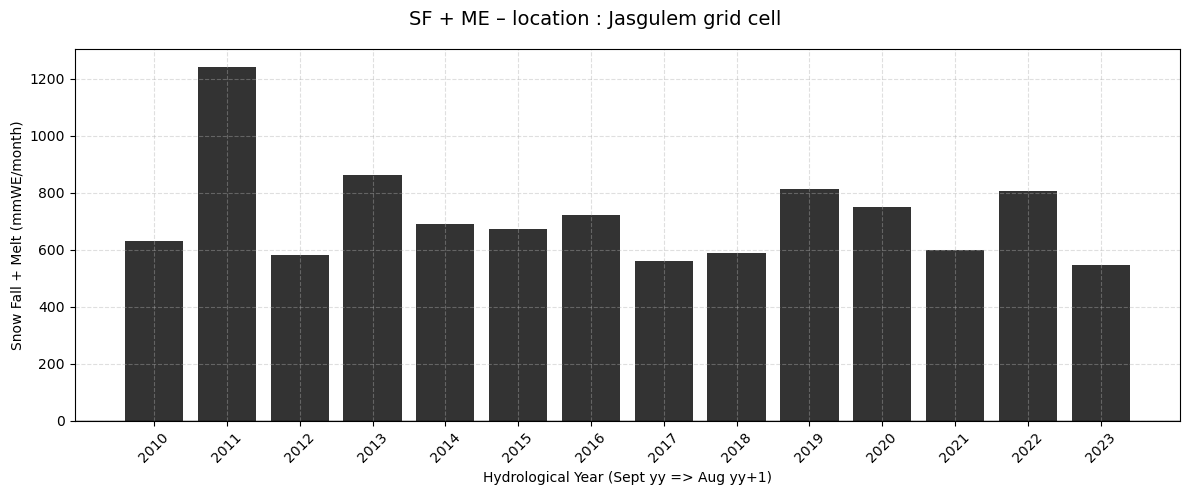

In [65]:
# Période cible
start_date = "2010-09-01"
end_date = "2024-08-31"

# Filtrage temporel
smb_filtered = {
    key: da.sel(time=slice(start_date, end_date))
    for key, da in smb_dataset.items()
}

# extraction pixel
smb_jasg = {
    key: da.isel(Y=iY, X=iX)
    for key, da in smb_filtered.items()
}

# SEB net
smb_net = (
    smb_jasg["SF"]
    + smb_jasg["ME"]

)

# =========================
# AGRÉGATION ANNUELLE (HYDRO YEAR SEP→AUG)
# =========================

smb_yearly = smb_net.resample(time="AS-SEP").sum()

# conversion propre des axes
years = smb_yearly["time.year"].values
values = smb_yearly.values

# =========================
# PLOT
# =========================

fig, ax = plt.subplots(figsize=(12, 5))

pos = np.where(values > 0, values, 0)
neg = np.where(values < 0, values, 0)

ax.bar(years, pos, color="black", alpha=0.8)
ax.bar(years, neg, color="gray", alpha=0.8)

ax.axhline(0, color="black", linewidth=1)

ax.set_ylabel("Snow Fall + Melt (mmWE/month)")
ax.set_xlabel("Hydrological Year (Sept yy => Aug yy+1)")

ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("SF + ME – location : Jasgulem grid cell", fontsize=14)

plt.tight_layout()
plt.show()

### Ci dessous version à garder

In [ ]:
# SMB = SF + RF - RU - SU - SW
# SMB = SF - ME + RZ - SU - SW

ds_SU = ds_SF - ds_SMB - ds_ME + ds-RZ - ds_SW

smb_dataset = {
    "SF": ds_SF,
    "ME":  ds_ME,   
    "RZ": ds_RZ,
    "SW": ds_SW,
    "SU": ds_SU
}

In [ ]:
# Période cible
start_date = "2010-09-01"
end_date = "2024-08-31"

# Filtrer les données temporellement
smb_filtered = {}
for key, da in smb_dataset.items():
    smb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
smb_jasg = {}
for key, da in smb_filtered.items():
    smb_jasg[key] = da.isel(Y=iY, X=iX)


# Composantes du SMB
components = ["SF", "ME", "RZ", "SW", "SU"]
labels = {
    "SF": "Snow Fall",
    "ME": "Melt",
    "RZ": "Refreezing",
    "SW": "Snow water",
    "SU": "Sublimation"
}

# Couleurs pour les histos
colors = {
    "SF": "#e41a1c", 
    "ME": "#377eb8", 
    "RZ": "#ff7f00", 
    "SW": "#984ea3", 
    "SU":  "#4daf4a",  
}

# Temps et données
time = smb_jasg[components[0]].time.values
data = np.array([smb_jasg[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(16, 7))

# Initialisation cumul
cumulative_pos = np.zeros_like(data[0])
cumulative_neg = np.zeros_like(data[0])

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        time,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        time,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("Energy flux (W m$^{-2}$)")
ax.set_xlabel("Time")

# Format date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Seasonnal surface mass balance – location : 2025 drilling Jasgulem gridd cell ", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Comparison with observations

In [32]:
obs_file = "field_accu_scenarios.txt"
obs_folder = "/bettik/fainx/MAR_HMA/field_data/pamir/"

ds_obs_accu =  np.loadtxt(obs_folder+obs_file, delimiter="\t",skiprows=1)

In [30]:
len(ds_obs_accu[:,6])

9

In [31]:
w = np.arange(len(ds_obs_accu))
w = w*(-1)
w = w+14

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


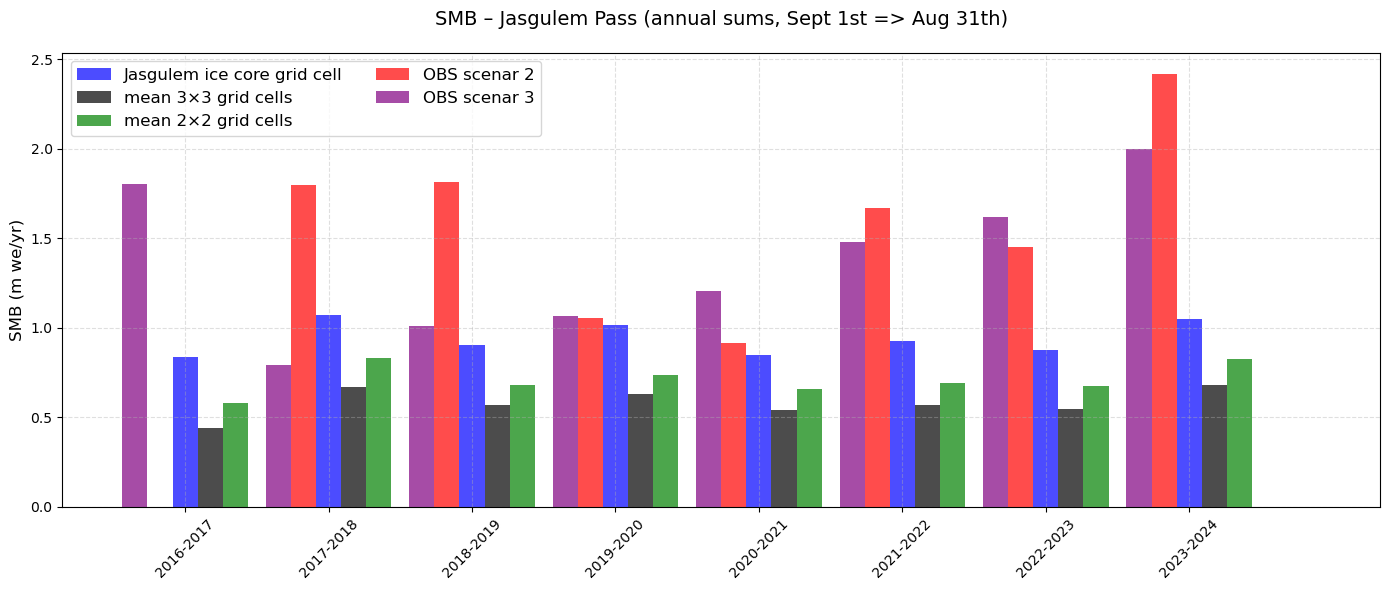

In [33]:
plt.figure(figsize=(14, 6))  # Figure large pour accueillir toutes les étiquettes

# Données
ds_SMB_jasg_annual = ds_SMB.isel(Y=iY, X=iX).resample(time="A-SEP").sum().sel(time=slice("2016-09-01", "2024-08-31")) / 1000
ds_SMB_jasg_annual_9cells = ds_SMB.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2)).mean(dim=["Y", "X"]).resample(time="A-SEP").sum().sel(time=slice("2016-09-01", "2024-08-31")) / 1000
ds_SMB_jasg_annual_4cells = ds_SMB.isel(Y=slice(iY-1, iY+1), X=slice(iX, iX+2)).mean(dim=["Y", "X"]).resample(time="A-SEP").sum().sel(time=slice("2016-09-01", "2024-08-31")) / 1000

# Largeur des barres
width = 0.35
x = np.arange(len(ds_SMB_jasg_annual.time))
w = np.arange(len(ds_obs_accu))*(-1)+16-8

# Tracé des barres
plt.bar(x , ds_SMB_jasg_annual, width/2, label="Jasgulem ice core grid cell", color="blue", alpha=0.7)
plt.bar(x + width/2, ds_SMB_jasg_annual_9cells, width/2, label="mean 3×3 grid cells", color="black", alpha=0.7)
plt.bar(x + width, ds_SMB_jasg_annual_4cells, width/2, label="mean 2×2 grid cells", color="green", alpha=0.7)
plt.bar(w - width/2, ds_obs_accu[:,5], width/2, label="OBS scenar 2", color="red", alpha=0.7)
plt.bar(w - width, ds_obs_accu[:,6], width/2, label="OBS scenar 3", color="purple", alpha=0.7)


# Création des labels "YYYY-YYYY"
years_start = ds_SMB_jasg_annual.time.dt.year.values
years_end = years_start + 1  # Chaque période va de l'année N à l'année N+1
labels = [f"{start}-{end}" for start, end in zip(years_start, years_end)]
plt.xticks(x, labels, rotation=45, ha='center', fontsize=10)

# Personnalisation des étiquettes x (toutes les années, rotation verticale)
years = ds_SMB_jasg_annual.time.dt.year.values
# plt.xticks(x, years, rotation=90, ha='center', fontsize=10)  # Rotation à 90°, alignement centré

# Ajustement des marges pour éviter le chevauchement
plt.subplots_adjust(bottom=0.3)  # Plus d'espace en bas

# Légende et titres
plt.legend(ncol=2, fontsize=12)
plt.title("SMB – Jasgulem Pass (annual sums, Sept 1st => Aug 31th)", fontsize=14, pad=20)
plt.ylabel("SMB (m we/yr)", fontsize=12)

# Grille et affichage
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()  # Ajuste automatiquement les marges
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


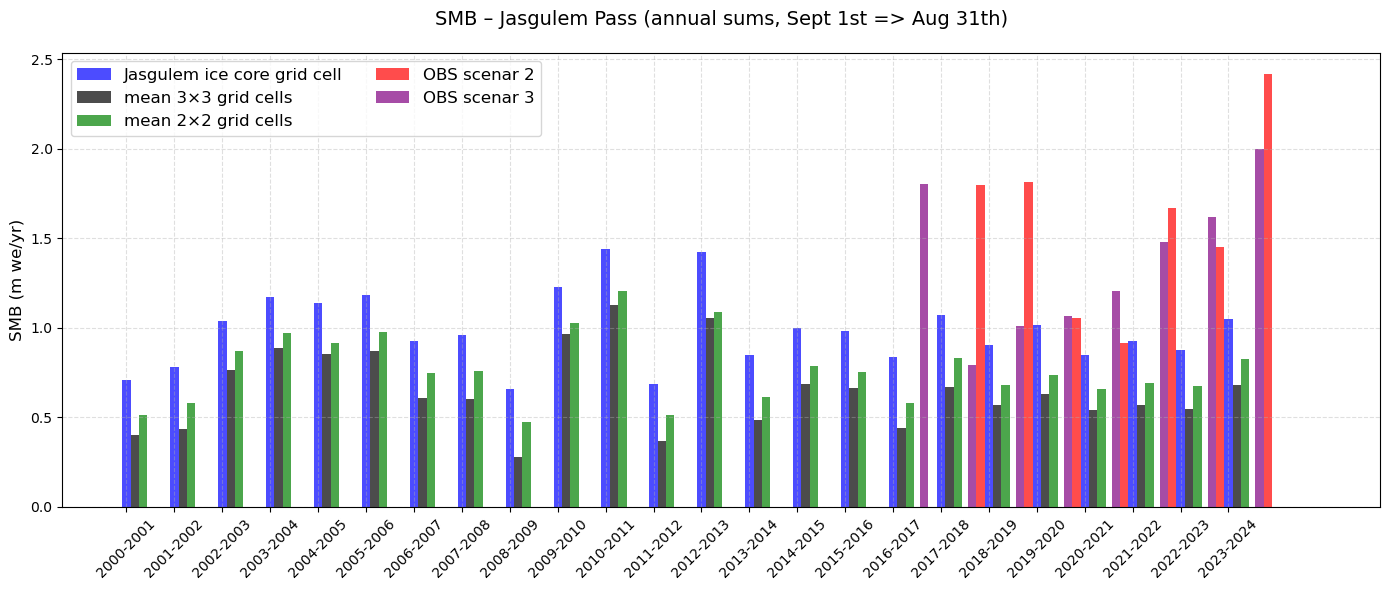

In [34]:
plt.figure(figsize=(14, 6)) 

# Données
ds_SMB_jasg_annual = ds_SMB.isel(Y=iY, X=iX).resample(time="A-SEP").sum().sel(time=slice("2000-09-01", "2024-08-31")) / 1000
ds_SMB_jasg_annual_9cells = ds_SMB.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2)).mean(dim=["Y", "X"]).resample(time="A-SEP").sum().sel(time=slice("2000-09-01", "2024-08-31")) / 1000
ds_SMB_jasg_annual_4cells = ds_SMB.isel(Y=slice(iY-1, iY+1), X=slice(iX, iX+2)).mean(dim=["Y", "X"]).resample(time="A-SEP").sum().sel(time=slice("2000-09-01", "2024-08-31")) / 1000

# Largeur des barres
width = 0.35
x = np.arange(len(ds_SMB_jasg_annual.time))
w = np.arange(len(ds_obs_accu))*(-1)+16+17-8

# Tracé des barres
plt.bar(x , ds_SMB_jasg_annual, width/2, label="Jasgulem ice core grid cell", color="blue", alpha=0.7)
plt.bar(x + width/2, ds_SMB_jasg_annual_9cells, width/2, label="mean 3×3 grid cells", color="black", alpha=0.7)
plt.bar(x + width, ds_SMB_jasg_annual_4cells, width/2, label="mean 2×2 grid cells", color="green", alpha=0.7)
plt.bar(w - width/2, ds_obs_accu[:,5], width/2, label="OBS scenar 2", color="red", alpha=0.7)
plt.bar(w - width, ds_obs_accu[:,6], width/2, label="OBS scenar 3", color="purple", alpha=0.7)

# Création des labels "YYYY-YYYY"
years_start = ds_SMB_jasg_annual.time.dt.year.values
years_end = years_start + 1  # Chaque période va de l'année N à l'année N+1
labels = [f"{start}-{end}" for start, end in zip(years_start, years_end)]
plt.xticks(x, labels, rotation=45, ha='center', fontsize=10)

# Personnalisation des étiquettes x (toutes les années, rotation verticale)
years = ds_SMB_jasg_annual.time.dt.year.values
# plt.xticks(x, years, rotation=90, ha='center', fontsize=10)  # Rotation à 90°, alignement centré

# Ajustement des marges pour éviter le chevauchement
plt.subplots_adjust(bottom=0.3)  # Plus d'espace en bas

# Légende et titres
plt.legend(ncol=2, fontsize=12)
plt.title("SMB – Jasgulem Pass (annual sums, Sept 1st => Aug 31th)", fontsize=14, pad=20)
plt.ylabel("SMB (m we/yr)", fontsize=12)

# Grille et affichage
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()  # Ajuste automatiquement les marges
plt.show()

## Correlations

In [48]:
# MAR data
ds_SMB_jasg_annual_1cell = ds_SMB_jasg.resample(time="A-SEP").sum().sel(time=slice("2016-09-01", "2024-08-31"))/1000
ds_SMB_jasg_mean_4cell = ds_SMB.isel(Y=slice(iY-1, iY+1), X=slice(iX, iX+2)).mean(dim=["Y", "X"]).resample(time="A-SEP").sum().sel(time=slice("2016-09-01", "2024-08-31"))/1000

# Obs
ds_obs_accu = ds_obs_accu[1:, :]
ds_obs_accu = ds_obs_accu[::-1, :]

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


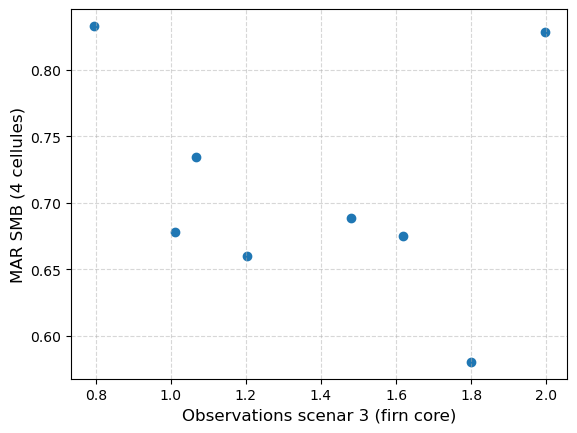

In [39]:
plt.scatter(ds_obs_accu[:, 6], ds_SMB_jasg_mean_4cell)

plt.xlabel("Observations scenar 3 (firn core)", fontsize=12)  
plt.ylabel("MAR SMB (4 cellules)", fontsize=12) 
# plt.title("", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [40]:
correlation = np.corrcoef(ds_SMB_jasg_mean_4cell, ds_obs_accu[:,6])[0, 1]
print(f"Coefficient de corrélation de Pearson Scenar 3: {correlation:.4f}")

Coefficient de corrélation de Pearson Scenar 3: -0.2025


### Obs ACC scenar 2

In [45]:
# Données
x = ds_obs_accu[1:, 5]
y = ds_SMB_jasg_mean_4cell[1:]

# régression linéaire
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
line = slope * x + intercept

# coefficient de Pearson (r_value) et la p-value
print(f"Coefficient de Pearson (r) : {r_value:.3f}")
print(f"P-value : {p_value:.3e}")

Coefficient de Pearson (r) : 0.626
P-value : 1.328e-01


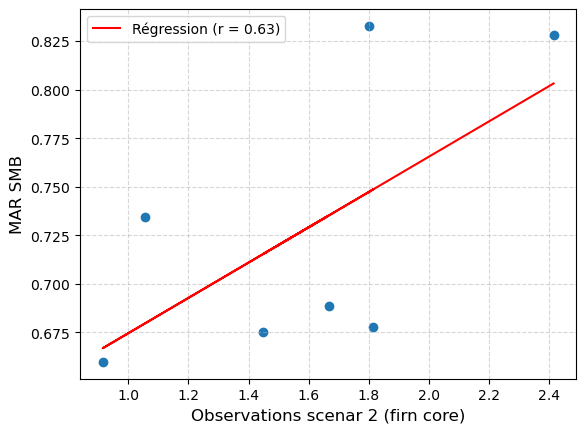

In [47]:
plt.scatter(x, y)

# Tracer la droite de régression
plt.plot(x, line, color='red', label=f'Régression (r = {r_value:.2f})')

# Ajouter les labels et le titre
plt.xlabel("Observations scenar 2 (firn core)", fontsize=12)
plt.ylabel("MAR SMB", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

# Ajouter la légende
plt.legend(fontsize=10)

# Afficher le graphique
plt.show()

### Obs ACC scenar 1

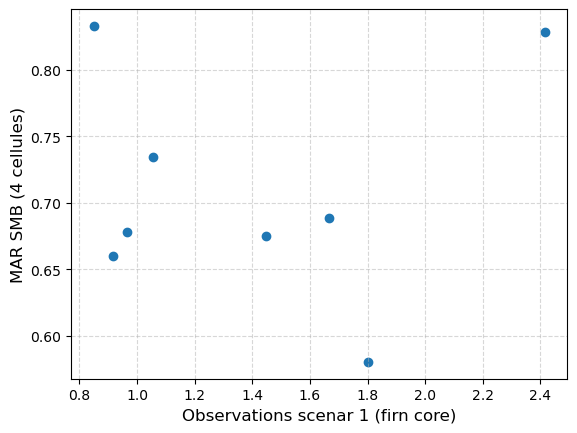

In [43]:
plt.scatter(ds_obs_accu[:, 4], ds_SMB_jasg_mean_4cell)

plt.xlabel("Observations scenar 1 (firn core)", fontsize=12)  
plt.ylabel("MAR SMB (4 cellules)", fontsize=12) 
# plt.title("", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [44]:
correlation = np.corrcoef(ds_SMB_jasg_mean_4cell, ds_obs_accu[:,4])[0, 1]
print(f"Coefficient de corrélation de Pearson Scenar 1: {correlation:.4f}")

Coefficient de corrélation de Pearson Scenar 1: 0.0693
